#  Task 1: Exploratory Data Analysis
# Insurance Risk Analytics – AlphaCare Insurance Solutions


In [1]:
import os
print(os.listdir('../data'))

['insurance_data.csv']


In [2]:
import pandas as pd
df = pd.read_csv('../data/insurance_data.csv', sep=';', encoding='latin1', nrows=5)
print(df.columns.tolist())

['UnderwrittenCoverID|PolicyID|TransactionMonth|IsVATRegistered|Citizenship|LegalType|Title|Language|Bank|AccountType|MaritalStatus|Gender|Country|Province|PostalCode|MainCrestaZone|SubCrestaZone|ItemType|mmcode|VehicleType|RegistrationYear|make|Model|Cylinders|cubiccapacity|kilowatts|bodytype|NumberOfDoors|VehicleIntroDate|CustomValueEstimate|AlarmImmobiliser|TrackingDevice|CapitalOutstanding|NewVehicle|WrittenOff|Rebuilt|Converted|CrossBorder|NumberOfVehiclesInFleet|SumInsured|TermFrequency|CalculatedPremiumPerTerm|ExcessSelected|CoverCategory|CoverType|CoverGroup|Section|Product|StatutoryClass|StatutoryRiskType|TotalPremium|TotalClaims']


In [3]:
# Load pipe-delimited file
df = pd.read_csv('../data/insurance_data.csv', sep='|', encoding='latin1')
print("Shape:", df.shape)
df.head()

C:\Users\Bitan\AppData\Local\Temp\ipykernel_14640\3405209209.py:2: DtypeWarning: Columns (0: CapitalOutstanding, 1: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/insurance_data.csv', sep='|', encoding='latin1')


Shape: (1000098, 52)


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


Shape: (1000098, 52)
                           dtype  missing  missing_pct
Bank                         str   145961    14.594670
AccountType                  str    40232     4.022806
MaritalStatus                str     8259     0.825819
Gender                       str     9536     0.953507
mmcode                   float64      552     0.055195
VehicleType                  str      552     0.055195
make                         str      552     0.055195
Model                        str      552     0.055195
Cylinders                float64      552     0.055195
cubiccapacity            float64      552     0.055195
kilowatts                float64      552     0.055195
bodytype                     str      552     0.055195
NumberOfDoors            float64      552     0.055195
VehicleIntroDate             str      552     0.055195
CustomValueEstimate      float64   779642    77.956560
CapitalOutstanding        object        2     0.000200
NewVehicle                   str   153295   

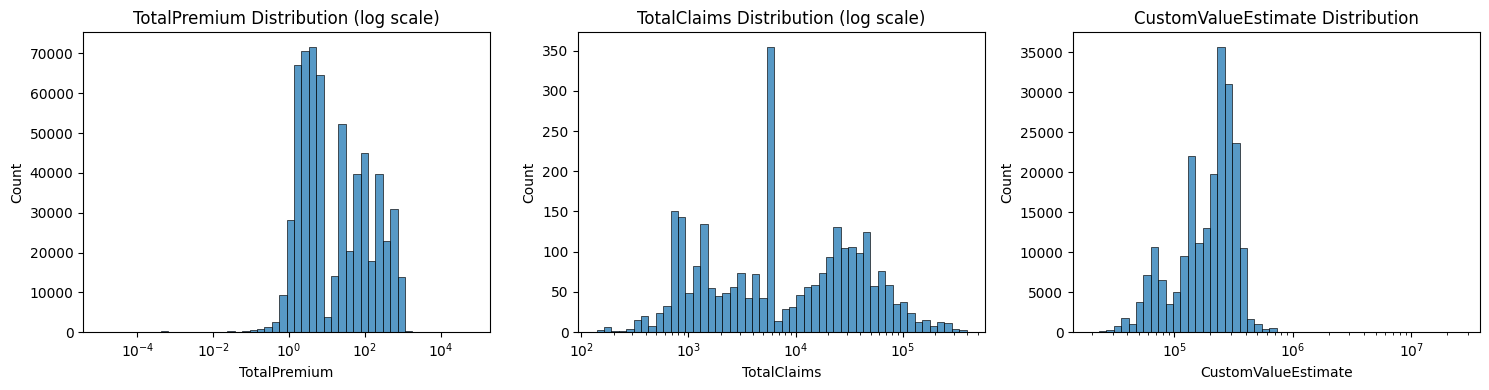

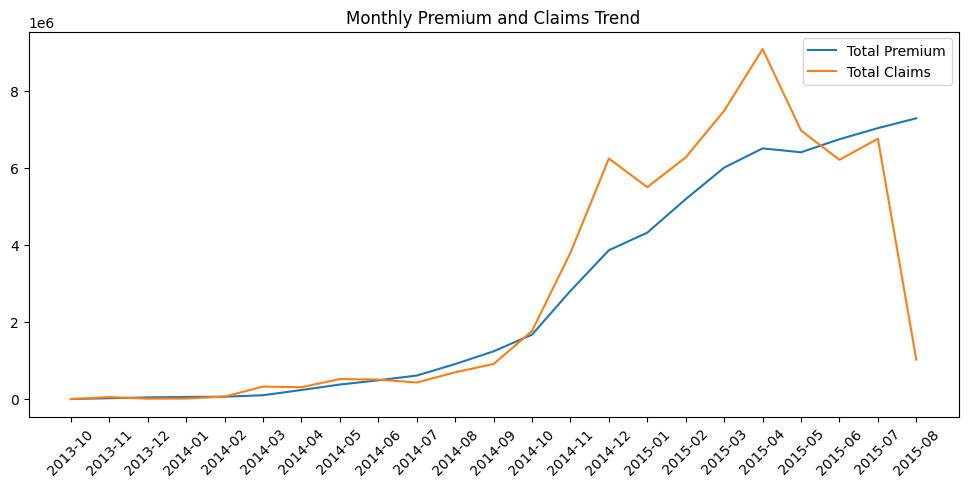

EDA completed – reports saved to ../reports/


In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load with pipe separator
df = pd.read_csv('../data/insurance_data.csv', sep='|', encoding='latin1')
print("Shape:", df.shape)
df.head()
# %%
# Data types and missing values
info_df = pd.DataFrame({
    'dtype': df.dtypes,
    'missing': df.isnull().sum(),
    'missing_pct': df.isnull().sum() / len(df) * 100
})
print(info_df[info_df['missing'] > 0])

# %%
# Derived metrics
df['LossRatio'] = df['TotalClaims'] / df['TotalPremium']
df['Margin'] = df['TotalPremium'] - df['TotalClaims']
df['ClaimOccurred'] = (df['TotalClaims'] > 0).astype(int)

# %%
overall_loss_ratio = df['TotalClaims'].sum() / df['TotalPremium'].sum()
print(f"Overall Loss Ratio: {overall_loss_ratio:.4f}")

# By Province
if 'Province' in df.columns:
    province_loss = df.groupby('Province').apply(
        lambda x: x['TotalClaims'].sum() / x['TotalPremium'].sum()
    ).sort_values()
    print("\nLoss Ratio by Province:\n", province_loss)

# %%
# Create reports folder if it doesn't exist
import os
os.makedirs('../reports', exist_ok=True)

# Distribution plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['TotalPremium'], bins=50, ax=axes[0], log_scale=True)
axes[0].set_title('TotalPremium Distribution (log scale)')
sns.histplot(df['TotalClaims'], bins=50, ax=axes[1], log_scale=True)
axes[1].set_title('TotalClaims Distribution (log scale)')
if 'CustomValueEstimate' in df.columns:
    sns.histplot(df['CustomValueEstimate'], bins=50, ax=axes[2], log_scale=True)
    axes[2].set_title('CustomValueEstimate Distribution')
plt.tight_layout()
plt.savefig('../reports/premium_claims_dist.png')
plt.show()

# %%
# Temporal trends
df['TransactionMonth'] = pd.to_datetime(df['TransactionMonth'])
monthly = df.groupby(df['TransactionMonth'].dt.to_period('M')).agg(
    total_premium=('TotalPremium', 'sum'),
    total_claims=('TotalClaims', 'sum'),
    claim_frequency=('ClaimOccurred', 'mean')
).reset_index()
monthly['TransactionMonth'] = monthly['TransactionMonth'].astype(str)

plt.figure(figsize=(12, 5))
plt.plot(monthly['TransactionMonth'], monthly['total_premium'], label='Total Premium')
plt.plot(monthly['TransactionMonth'], monthly['total_claims'], label='Total Claims')
plt.xticks(rotation=45)
plt.legend()
plt.title('Monthly Premium and Claims Trend')
plt.savefig('../reports/temporal_trend.png')
plt.show()

print("EDA completed – reports saved to ../reports/")